In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [3]:
# ------------------------------------------------------------------
# CONFIGURACIÓN: editá estas variables según lo que necesites
# ------------------------------------------------------------------
ARCHIVO = "Analisis_Exploratorio_de_Datos_VJ.xlsx"          # nombre (o ruta) del archivo Excel
COLUMNA = "jugadores (descargas)"              # nombre de la columna a analizar
# ------------------------------------------------------------------

C:\Users\Gasti\AppData\Local\Temp\ipykernel_9892\821425533.py:47: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax1.boxplot(datos, whis=[0, 100], vert=True)
C:\Users\Gasti\AppData\Local\Temp\ipykernel_9892\821425533.py:54: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax2.boxplot(datos, whis=1.5, vert=True)


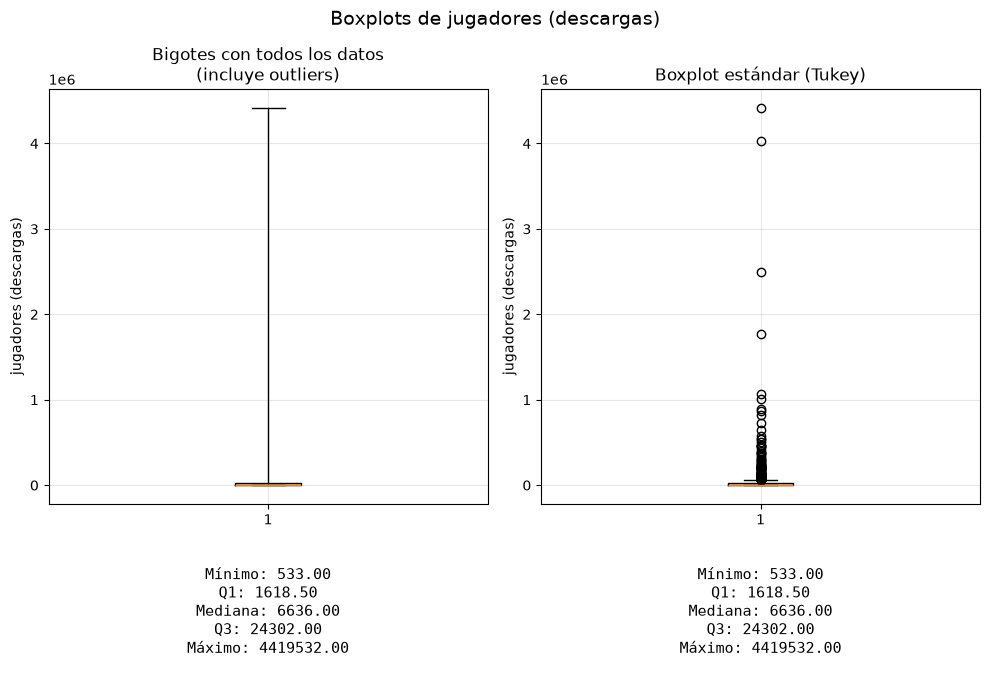

In [4]:
def cargar_datos(archivo: str, columna: str) -> pd.Series:
    ruta = archivo if os.path.isabs(archivo) else os.path.join(os.getcwd(), archivo)

    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")

    df = pd.read_excel(ruta)

    if columna not in df.columns:
        raise ValueError(
            f"La columna '{columna}' no existe en el archivo. "
            f"Columnas disponibles: {list(df.columns)}"
        )

    datos = pd.to_numeric(df[columna], errors="coerce").dropna()

    if datos.empty:
        raise ValueError(f"La columna '{columna}' no tiene datos numéricos.")

    return datos


def resumen_cinco_numeros(datos: pd.Series) -> dict:
    return {
        "Mínimo": datos.min(),
        "Q1": datos.quantile(0.25),
        "Mediana": datos.median(),
        "Q3": datos.quantile(0.75),
        "Máximo": datos.max(),
    }


def texto_resumen(resumen: dict) -> str:
    return "\n".join(f"{nombre}: {valor:.2f}" for nombre, valor in resumen.items())


def main():
    datos = cargar_datos(ARCHIVO, COLUMNA)
    resumen = resumen_cinco_numeros(datos)
    texto = texto_resumen(resumen)

    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], figure=fig)

    # Boxplot 1: los bigotes cubren todo el rango (incluye los outliers dentro de ellos)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.boxplot(datos, whis=[0, 100], vert=True)
    ax1.set_title("Bigotes con todos los datos\n(incluye outliers)")
    ax1.set_ylabel(COLUMNA)
    ax1.grid(alpha=0.3)

    # Boxplot 2: boxplot estándar de Tukey (bigotes = 1.5 * RIC, outliers aparte)
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.boxplot(datos, whis=1.5, vert=True)
    ax2.set_title("Boxplot estándar (Tukey)")
    ax2.set_ylabel(COLUMNA)
    ax2.grid(alpha=0.3)

    # Resumen de los 5 números, debajo de cada boxplot
    ax1_texto = fig.add_subplot(gs[1, 0])
    ax1_texto.axis("off")
    ax1_texto.text(0.5, 0.5, texto, ha="center", va="center", fontsize=11, family="monospace")

    ax2_texto = fig.add_subplot(gs[1, 1])
    ax2_texto.axis("off")
    ax2_texto.text(0.5, 0.5, texto, ha="center", va="center", fontsize=11, family="monospace")

    fig.suptitle(f"Boxplots de {COLUMNA}", fontsize=14)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()